# 06 — Phase 2 v0: Feature Snapshot EDA

Reads the engineered feature output from
`s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/` (via the
`_latest.json` run pointer written by notebook 05) and runs exploratory
checks: nulls, coverage by day, delay distribution by mode, and a delay
heatmap by hour/day-of-week. Read-only — nothing is written back to S3.

In [1]:
# Cell 1 — Environment setup: load .env, configure S3 access, display options
import os
import subprocess
import sys
import json
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv, find_dotenv

try:
    import s3fs
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 's3fs', '-q'], check=True)
    import s3fs

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_dotenv_path = find_dotenv(usecwd=True)
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f'Loaded .env from: {_dotenv_path}')
else:
    print('No .env file found — using defaults.')

S3_BUCKET = os.environ.get('AWS_S3_BUCKET', '')
AWS_REGION = os.environ.get('AWS_REGION', 'ap-southeast-2')
REPO_DIR   = os.environ.get('TRANSIT_AI_REPO_DIR', str(Path.cwd().parent))

if not S3_BUCKET:
    raise EnvironmentError('AWS_S3_BUCKET is not set. Check your .env file.')

fs = s3fs.S3FileSystem()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

print(f'S3_BUCKET: {S3_BUCKET}')
print(f'AWS_REGION: {AWS_REGION}')
print(f'REPO_DIR: {REPO_DIR}')

Loaded .env from: /Users/proteeksanyal/Desktop/Learning/Transit-AI/.env
S3_BUCKET: seq-transit-ai-data-ps
AWS_REGION: ap-southeast-2
REPO_DIR: /Users/proteeksanyal/Desktop/Learning/Transit-AI


In [2]:
# Cell 2 — Load feature snapshot via _latest.json run pointer (with fallback)
RUN_DATE_OVERRIDE = None  # set to a 'YYYY-MM-DD' string to inspect a past run instead of latest

ML_FEATURES_PREFIX = f'{S3_BUCKET}/ml_features/v0_feature_snapshot'

if RUN_DATE_OVERRIDE is not None:
    RUN_DATE = RUN_DATE_OVERRIDE
    load_path = f's3://{ML_FEATURES_PREFIX}/run_date={RUN_DATE}/'
    print(f'RUN_DATE_OVERRIDE set — loading run_date={RUN_DATE} directly (bypassing _latest.json)')
else:
    manifest_path = f's3://{ML_FEATURES_PREFIX}/_latest.json'
    try:
        with fs.open(manifest_path) as f:
            manifest = json.load(f)
        RUN_DATE = manifest['latest_run']
        load_path = f's3://{ML_FEATURES_PREFIX}/run_date={RUN_DATE}/'
        print(f'_latest.json found -> latest_run={RUN_DATE}')
    except FileNotFoundError:
        print(
            f'WARNING: {manifest_path} not found. No versioned run available yet.\n'
            f'Falling back to reading directly from s3://{ML_FEATURES_PREFIX}/ '
            '(no run_date partition).'
        )
        RUN_DATE = None
        load_path = f's3://{ML_FEATURES_PREFIX}/'

df = pd.read_parquet(load_path)

print(f'\nLoaded {len(df):,} rows x {df.shape[1]} cols from {load_path}')
print(df.dtypes)

_latest.json found -> latest_run=2026-07-07



Loaded 833,047 rows x 14 cols from s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/run_date=2026-07-07/
trip_id                                               object
route_id                                              object
stop_id                                               object
mode                                                  object
snapshot_timestamp        datetime64[ns, Australia/Brisbane]
scheduled_arrival_time                                object
stop_sequence                                          Int64
delay_seconds                                        float64
delay_minutes                                        float64
hour_of_day                                            int32
day_of_week                                           object
is_weekend                                              bool
is_peak                                                 bool
source_date                                         category
dtype: object


## Head

In [3]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
trip_id,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802,37417780-MET 26_27-42802
route_id,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154,M2-4154
stop_id,897,891,884,893,10792,10780,11168,19064,19063,10798
mode,bus,bus,bus,bus,bus,bus,bus,bus,bus,bus
snapshot_timestamp,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00,2026-07-05 05:10:22+10:00
scheduled_arrival_time,05:36:00,05:38:00,05:39:00,05:41:00,05:43:00,05:44:00,05:47:00,05:49:00,05:51:00,05:54:00
stop_sequence,1,2,3,4,5,6,7,8,9,10
delay_seconds,NaN,-21.0,-6.0,-47.0,-50.0,39.0,-36.0,-28.0,-71.0,-46.0
delay_minutes,NaN,-0.35,-0.1,-0.783333,-0.833333,0.65,-0.6,-0.466667,-1.183333,-0.766667
hour_of_day,5,5,5,5,5,5,5,5,5,5


## Null % per column

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
print(null_pct.to_string())

trip_id                   0.00
route_id                  0.00
stop_id                   0.00
mode                      0.00
snapshot_timestamp        0.00
scheduled_arrival_time    0.00
stop_sequence             0.00
delay_seconds             2.71
delay_minutes             2.71
hour_of_day               0.00
day_of_week               0.00
is_weekend                0.00
is_peak                   0.00
source_date               0.00


## Row count by source_date

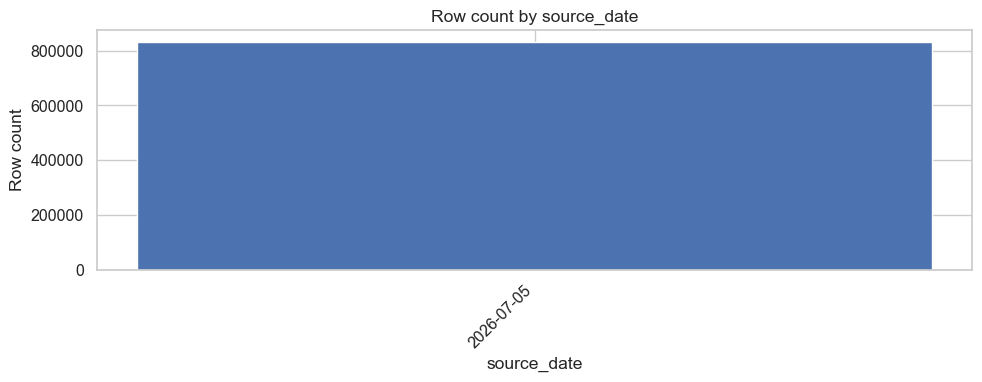

In [5]:
counts_by_day = df['source_date'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts_by_day.index.astype(str), counts_by_day.values, color='#4C72B0')
ax.set_title('Row count by source_date')
ax.set_xlabel('source_date')
ax.set_ylabel('Row count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Null map

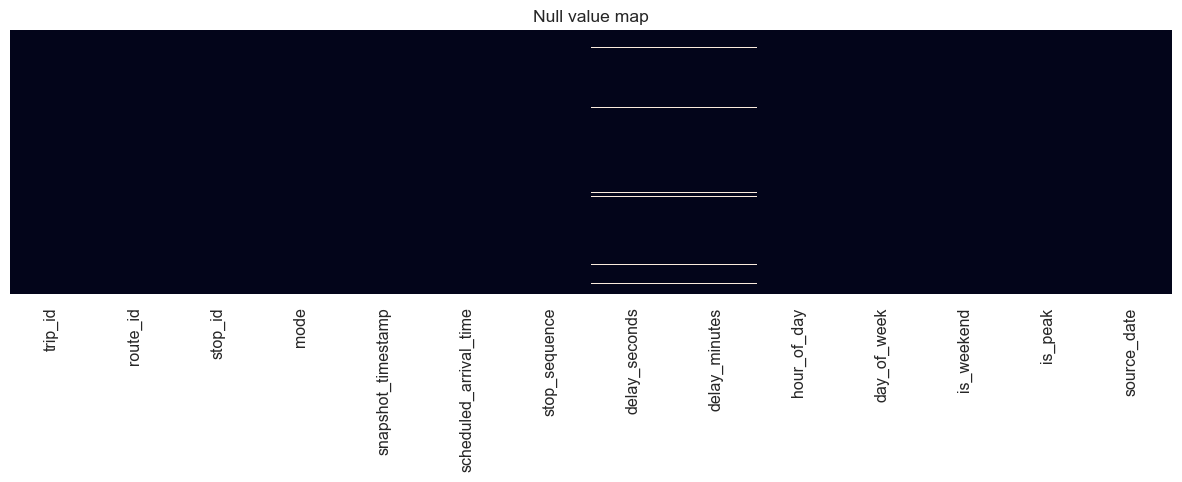

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax)
ax.set_title('Null value map')
plt.tight_layout()
plt.show()

## Delay by mode

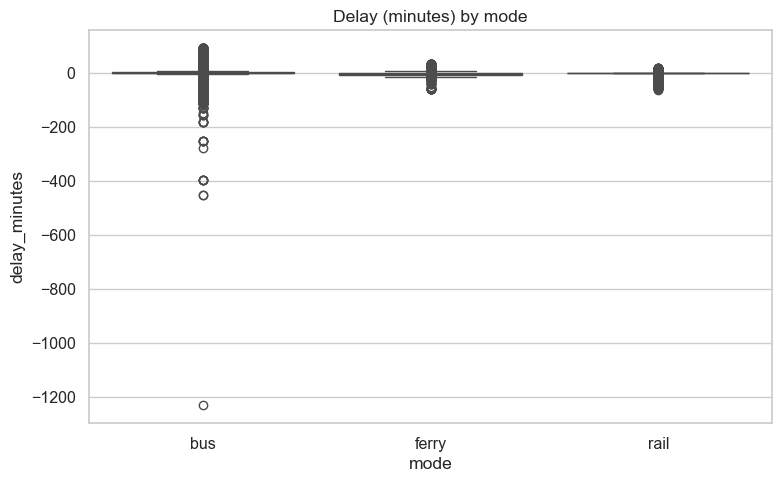

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='mode', y='delay_minutes', ax=ax)
ax.set_title('Delay (minutes) by mode')
plt.tight_layout()
plt.show()

## Correlation matrix

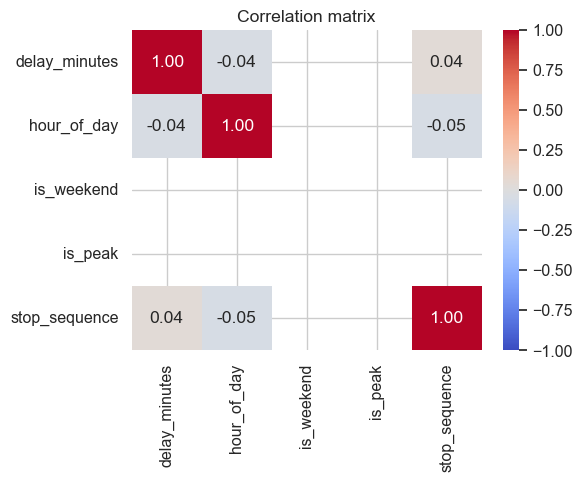

In [8]:
corr_cols = ['delay_minutes', 'hour_of_day', 'is_weekend', 'is_peak', 'stop_sequence']
corr_df = df[corr_cols].copy()
corr_df['is_weekend'] = corr_df['is_weekend'].astype(int)
corr_df['is_peak'] = corr_df['is_peak'].astype(int)
corr_df['stop_sequence'] = pd.to_numeric(corr_df['stop_sequence'], errors='coerce')

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

## Mean delay by hour of day x day of week

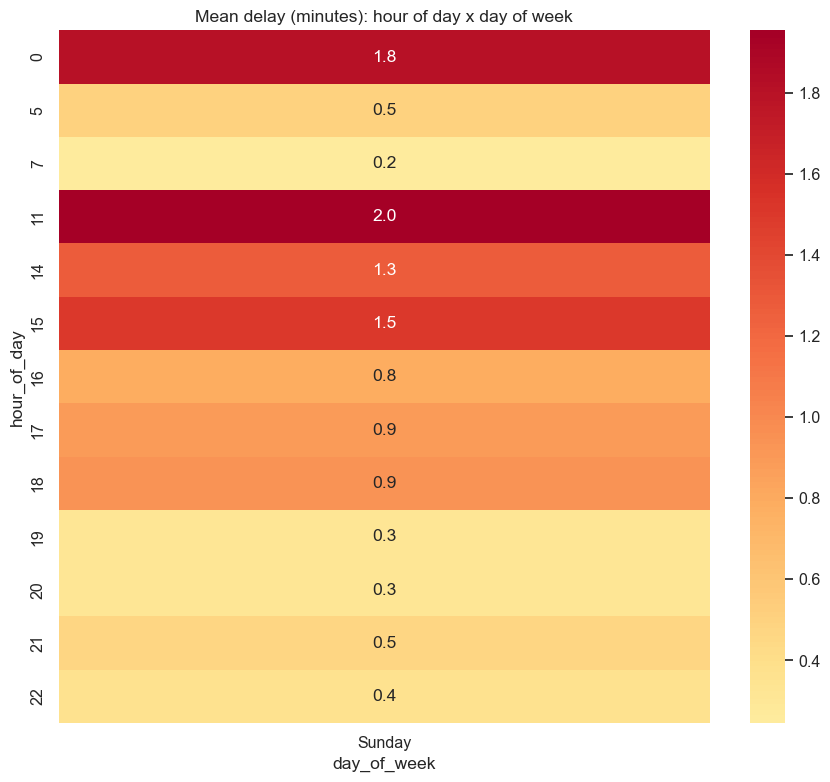

In [9]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df.pivot_table(
    index='hour_of_day', columns='day_of_week', values='delay_minutes', aggfunc='mean'
)
pivot = pivot.reindex(columns=[d for d in DAY_ORDER if d in pivot.columns])

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0, annot=True, fmt='.1f', ax=ax)
ax.set_title('Mean delay (minutes): hour of day x day of week')
plt.tight_layout()
plt.show()

## Null investigation — mode breakdown where delay_seconds is null

In [10]:
print("mode value_counts() for rows where delay_seconds is null:")
print(df.loc[df['delay_seconds'].isnull(), 'mode'].value_counts())

mode value_counts() for rows where delay_seconds is null:
mode
bus      18793
ferry     2225
rail      1527
Name: count, dtype: int64
